# **Final Code for the TB Detection**

This is the final code of the TB Detection which Daan and Gibran worked on through multiple meetings. The improvment was mostly done by Daan. We were able to fix a lot of errors and overall improve the model itself by fixing the image processing and improving the model.

# Import Libraries

In [ ]:
import os
import cv2
import glob
import joblib
import numpy as np
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt

from scipy.signal import find_peaks
from skimage.measure import label, regionprops
from skimage.measure import shannon_entropy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Import Testing Image

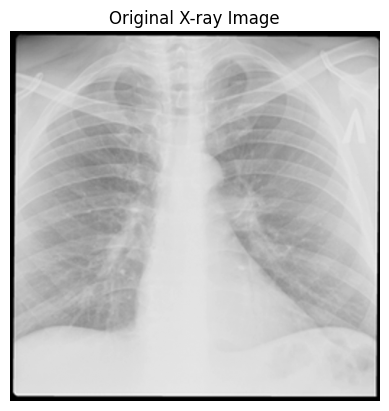

In [ ]:
# Load test image
test_img = cv2.imread('Tuberculosis-10.png', cv2.IMREAD_GRAYSCALE)

# Display test image
plt.imshow(test_img, cmap='gray')
plt.title('Original X-ray Image')
plt.axis('off')
plt.show()


# Pre-Processing Function

In [ ]:
# Define the default (our) preprocessing pipeline
default_config = {
    "normalize": True,
    "clahe_enhance": True,
    "median_filter": True,
    "gaussian_filter": True,
    "sharpen": True
}

def preprocess_image(image, config=default_config):

    # Initialize the return object
    results = {"original": image}

    # Create a copy of the image to preprocess
    current = image.copy()

    # Remove the black borders around the input image
    current[current < 20] = 255

    # Perform normalization
    if config["normalize"]:
        normalized = cv2.normalize(current, None, alpha=0, beta=1,
                                   norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)
        results["normalized"] = normalized
        current = (normalized * 255).astype(np.uint8)

    # Perform histogram enhancement
    if config["clahe_enhance"]:
      equalized = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(current)
      results["clahe_enhanced"] = equalized
      current = equalized.astype(np.uint8)

    # Perform median filtering
    if config["median_filter"]:
      median_filtered = cv2.medianBlur(current, 3)
      results["median_filtered"] = median_filtered
      current = median_filtered.astype(np.uint8)

    # Perform gaussian filtering
    if config["gaussian_filter"]:
      gaussian_filtered = cv2.GaussianBlur(current, (5, 5), 0)
      results["gaussian_filtered"] = gaussian_filtered
      current = gaussian_filtered.astype(np.uint8)

    # Perform sharpening
    if config["sharpen"]:
      laplacian = cv2.Laplacian(current, cv2.CV_64F)
      sharpened = cv2.convertScaleAbs(gaussian_filtered - 0.5 * laplacian)
      results["sharpened"] = sharpened
      current = sharpened.astype(np.uint8)

    # Add the output of the pipeline to the return object as final result
    results["final"] = current

    return results

# Display Pre-Processing Results

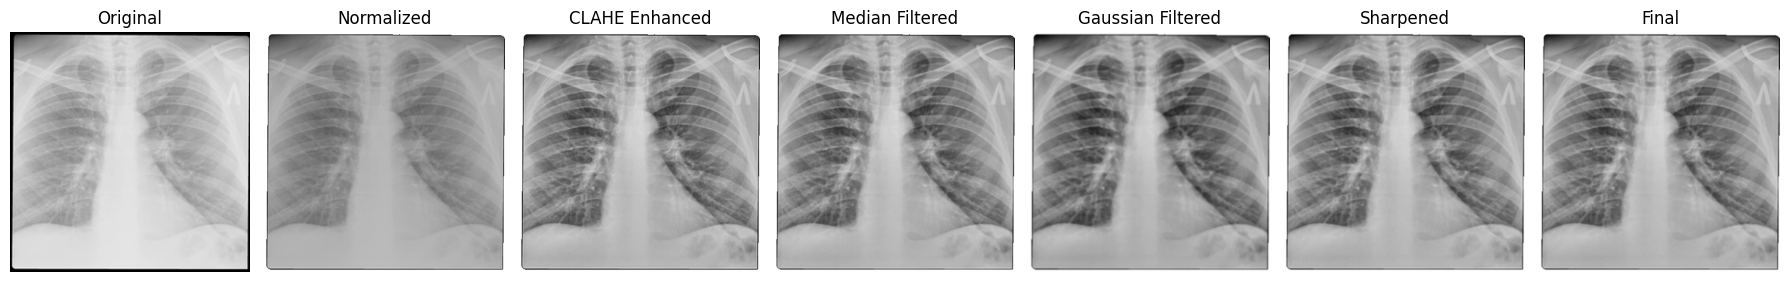

In [ ]:
# Preprocess the testing image
results = preprocess_image(test_img)

# Display the different preprocessing stages
titles = ['Original', 'Normalized', 'CLAHE Enhanced', 'Median Filtered', 'Gaussian Filtered', 'Sharpened', 'Final']
images = [
    results['original'],
    results['normalized'],
    results['clahe_enhanced'],
    results['median_filtered'],
    results['gaussian_filtered'],
    results['sharpened'],
    results['final']
]

# Plot image
plt.figure(figsize=(18, 6))
for i in range(len(images)):
    plt.subplot(1, len(images), i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


# Lung Segmentation Function (Otsu + Morphology)

In [ ]:
def segment_lungs(img):

    # Use Otsu's method to find the optimal threshold
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    thresh = cv2.bitwise_not(thresh)

    # Perform morphological processing (opening --> closing)
    kernel_open = np.ones((3, 3), np.uint8)
    kernel_close = np.ones((7, 7), np.uint8)
    opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_open, iterations=2)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_close, iterations=2)

    # Initialize masks
    mask_empty = np.zeros_like(img, dtype=np.uint8)
    mask_left = mask_empty.copy()
    mask_right = mask_empty.copy()
    mask_combined = mask_empty.copy()

    # Find connected components within the mask
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closed, connectivity=8)

    # If we don't find any lungs, return empty masks
    if num_labels <= 1:
        return {
            "thresholded": thresh,
            "morph_cleaned": closed,
            "mask_left": mask_empty,
            "mask_right": mask_empty,
            "mask_combined": mask_empty,
            "image_segmented": mask_empty
        }

    # Compute the size of each mask
    mask_sizes = stats[1:, cv2.CC_STAT_AREA]

    # If we find 2 or more lungs
    if len(mask_sizes) >= 2:

        # Find the two largest masks
        largest_idxs = np.argsort(mask_sizes)[-2:] + 1

        x0 = stats[largest_idxs[0], cv2.CC_STAT_LEFT]
        x1 = stats[largest_idxs[1], cv2.CC_STAT_LEFT]

        # Determine which mask is left / right
        if x0 < x1:
            mask_left[labels == largest_idxs[0]] = 255
            mask_right[labels == largest_idxs[1]] = 255
        else:
            mask_left[labels == largest_idxs[1]] = 255
            mask_right[labels == largest_idxs[0]] = 255

    # If we find only a single lung (left/right are merged)
    else:

        mask_combined[labels == 1] = 255

        # Perform erosion to increase the gap between left and right lung
        mask_eroded = cv2.erode(mask_combined, np.ones((5, 5), np.uint8), iterations=1)

        # Compute the masked number of pixels per column and smoothen
        col_sum = np.sum(mask_eroded, axis=0)
        col_sum_smooth = cv2.GaussianBlur(col_sum.astype(np.float32), (21, 1), 0).ravel()

        # Find the peeks (lungs) in this array
        peaks, _ = find_peaks(
            col_sum_smooth,
            distance=img.shape[1] // 6,
            prominence=0.2 * np.max(col_sum_smooth)
        )

        # Use the two largest peaks
        if len(peaks) >= 2:
            peak_vals = col_sum_smooth[peaks]
            largest_two = peaks[np.argsort(peak_vals)[-2:]]
            left_peak, right_peak = np.sort(largest_two)
            split_col = np.argmin(col_sum_smooth[left_peak:right_peak+1]) + left_peak

        # If the method fails, split lungs in the middle
        else:
            split_col = mask_combined.shape[1] // 2

        # Create all masks
        mask_left = mask_combined.copy()
        mask_right = mask_combined.copy()
        mask_left[:, split_col:] = 0
        mask_right[:, :split_col] = 0

    # Combine left and right masks
    mask_combined = cv2.bitwise_or(mask_left, mask_right)
    image_segmented = cv2.bitwise_and(img, img, mask=mask_combined)

    return {
        "thresholded": thresh,
        "morph_cleaned": closed,
        "mask_left": mask_left,
        "mask_right": mask_right,
        "mask_combined": mask_combined,
        "image_segmented": image_segmented
    }

# Display Segmentation Results

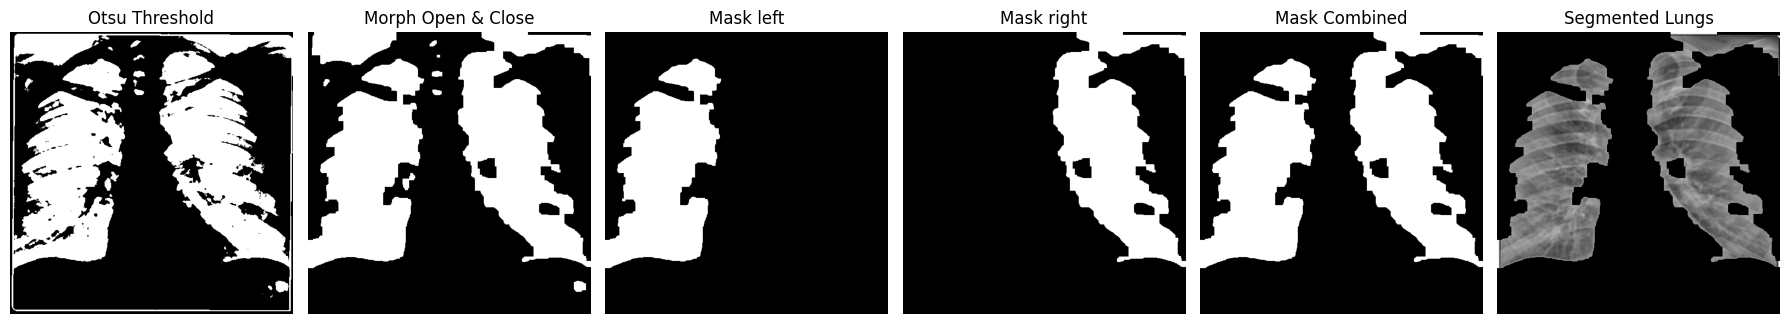

In [ ]:
# Perform preprocessing on testing image
test_img_preprocessed = preprocess_image(test_img)['final']

# Perform segmentation on testing image
segmentation_output = segment_lungs(test_img_preprocessed)

# Display the different segmented masks
titles = ['Otsu Threshold', 'Morph Open & Close', 'Mask left', 'Mask right', 'Mask Combined', 'Segmented Lungs']
images = [
    segmentation_output['thresholded'],
    segmentation_output['morph_cleaned'],
    segmentation_output['mask_left'],
    segmentation_output['mask_right'],
    segmentation_output['mask_combined'],
    segmentation_output['image_segmented']
]

# Plot the figure
plt.figure(figsize=(18, 6))
for i in range(len(images)):
    plt.subplot(1, len(images), i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


# Lung Feature Extraction

In [ ]:
def extract_lung_features(image, mask):

    # Initialize return object
    features = []

    # Initialize a copy of the image to annotate
    if len(image.shape) == 2:
        annotated_img = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    else:
        annotated_img = image.copy()

    # Split the binary mask into (two) connected components
    labeled_mask = label(mask)

    # Extract the properties of each connected component
    for region in regionprops(labeled_mask, intensity_image=image):

        # Ignore small regions
        if region.area < 5000:
            continue

        # Extract area and perimeter features
        area = region.area
        perimeter = region.perimeter
        centroid = region.centroid
        bbox = region.bbox

        # Extract intensity features
        mean_intensity = region.mean_intensity
        std_intensity = np.std(image[labeled_mask == region.label])
        entropy = shannon_entropy(image[labeled_mask == region.label])

        # Append features to return object
        features.append({
            "label": region.label,
            "area": area,
            "perimeter": perimeter,
            "centroid": centroid,
            "mean_intensity": mean_intensity,
            "std_intensity": std_intensity,
            "entropy": entropy
        })

        # Draw bounding box around connected component
        (minr, minc, maxr, maxc) = bbox
        cv2.rectangle(annotated_img, (minc, minr), (maxc, maxr), (0, 255, 0), 2)
        cv2.circle(annotated_img, (int(centroid[1]), int(centroid[0])), 4, (0, 0, 255), -1)
        cv2.putText(annotated_img, f"Lung {region.label}", (minc, minr - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)

    return annotated_img, features


#Display Feature Extraction Result

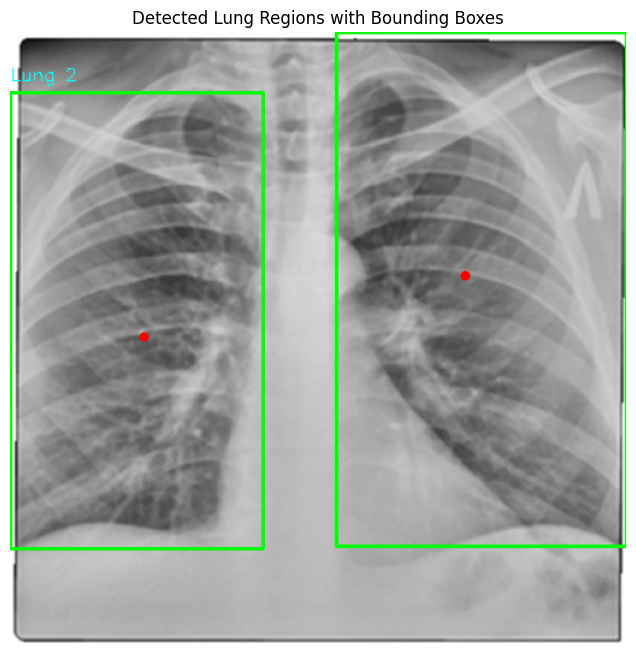

,label,area,perimeter,centroid,mean_intensity,std_intensity,entropy
0,1,51610.0,2230.212337,"(202.8386359232707, 378.44316992830846)",122.519531,26.347882,6.369244
1,2,46967.0,1581.477272,"(253.70832712329934, 111.69327400089425)",123.418656,22.782068,6.268901


In [ ]:
# Preprocess the testing image
test_img_preprocessed = preprocess_image(test_img)['final']

# Perform segmentation on testing image
test_img_segmented = segment_lungs(test_img_preprocessed)

# Extract the binary mask and segmented image
mask = test_img_segmented['mask_combined']
segmented = test_img_segmented['image_segmented']

# Perform feature extraction on testing image
annotated_img, lung_features = extract_lung_features(test_img_preprocessed, mask)

# Display the annotated image
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Lung Regions with Bounding Boxes")
plt.axis("off")
plt.show()

# Print the feature dataframe
pd.DataFrame(lung_features)


# **Training the Model**

## 1. Download Kaggle Dataset

In [ ]:
# Request a kaggle.json file from the user
print("Please upload a kaggle.json file:")
files.upload()

Please upload a kaggle.json file:


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"gibranbasyir","key":"8269b19eb60086dbd479c69607bb05c4"}'}

In [ ]:
# Install Kaggle and move the kaggle.json file
!pip install kaggle --quiet
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d tawsifurrahman/tuberculosis-tb-chest-xray-dataset

# Unzip the dataset to relevant folder
!mkdir -p /content/data
!unzip tuberculosis-tb-chest-xray-dataset.zip -d /content/data

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
License(s): copyright-authors
 95% 633M/663M [00:10<00:00, 64.8MB/s]
100% 663M/663M [00:10<00:00, 63.3MB/s]
Archive:  tuberculosis-tb-chest-xray-dataset.zip
  inflating: /content/data/TB_Chest_Radiography_Database/Normal.metadata.xlsx  
  inflating: /content/data/TB_Chest_Radiography_Database/Normal/Normal-1.png  
  inflating: /content/data/TB_Chest_Radiography_Database/Normal/Normal-10.png  
  inflating: /content/data/TB_Chest_Radiography_Database/Normal/Normal-100.png  
  inflating: /content/data/TB_Chest_Radiography_Database/Normal/Normal-1000.png  
  inflating: /content/data/TB_Chest_Radiography_Database/Normal/Normal-1001.png  
  inflating: /content/data/TB_Chest_Radiography_Database/Normal/Normal-1002.png  
  inflating: /content/data/TB_Chest_Radiography_Database/Normal/Normal-1003.png  
  inflating: /content/data/TB_Chest_Radiography_Database/Normal/Normal-1004.png  
  inflating: /cont

### 2. Convert Features to Proper Format (Helper Function)

In [ ]:
def process_image_features(dataframe):

    # Ensure the dataframe contains two lung regions
    if not dataframe or len(dataframe) != 2:
        print("Warning: Did not find exactly two lungs in an image. Skipping.")
        return None

    # Check which lung is left/right
    if dataframe[0]['centroid'][1] < dataframe[1]['centroid'][1]:
        left_lung = dataframe[0]
        right_lung = dataframe[1]
    else:
        left_lung = dataframe[1]
        right_lung = dataframe[0]

    # Extract features and return as a single row
    row = {
        'left_area': left_lung['area'],
        'left_perimeter': left_lung['perimeter'],
        'left_mean_intensity': left_lung['mean_intensity'],
        'left_std_intensity': left_lung['std_intensity'],
        'left_entropy': left_lung['entropy'],

        'right_area': right_lung['area'],
        'right_perimeter': right_lung['perimeter'],
        'right_mean_intensity': right_lung['mean_intensity'],
        'right_std_intensity': right_lung['std_intensity'],
        'right_entropy': right_lung['entropy'],

        'area_diff': left_lung['area'] - right_lung['area'],
        'entropy_diff': left_lung['entropy'] - right_lung['entropy'],
        'intensity_diff': left_lung['mean_intensity'] - right_lung['mean_intensity']
    }

    return row

### 3. Preprocess Dataset & Feature Extraction

In [ ]:
# Paths to the Normal and TB images (hard coded)
NORMAL_PATH = "/content/data/TB_Chest_Radiography_Database/Normal/*.png"
TB_PATH = "/content/data/TB_Chest_Radiography_Database/Tuberculosis/*.png"

# Initialize feature and label lists
all_features_list = []
all_labels_list = []



# Start by preprocessing normal (healthy) images
print(f"Processing healthy images from: {NORMAL_PATH}")
for img_path in glob.glob(NORMAL_PATH):

    # Read the image from path
    original_image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # Ensure image was loaded properly
    if original_image is None:
        print(f"Warning: Could not read image {img_path}. Skipping.")
        continue

    # Preprocess image
    preprocessed_img = preprocess_image(original_image)['final']

    # Segment image
    segmented_image = segment_lungs(preprocessed_img)['mask_combined']

    # Perform feature extraction
    annotated_img, features = extract_lung_features(preprocessed_img, segmented_image)

    # Convert features into proper format
    row = process_image_features(features)

    # Append features and label to relevant lists
    if row:
        all_features_list.append(row)
        all_labels_list.append(0)



# Continue by preprocessing tuberculosis images
print(f"Processing tuberculosis images from: {TB_PATH}")
for img_path in glob.glob(TB_PATH):

    # Read the image from path
    original_image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # Ensure image was loaded properly
    if original_image is None:
        print(f"Warning: Could not read image {img_path}. Skipping.")
        continue

    # Preprocess image
    preprocessed_img = preprocess_image(original_image)['final']

    # Segment image
    segmented_image = segment_lungs(preprocessed_img)['mask_combined']
    annotated_img, features = extract_lung_features(preprocessed_img, segmented_image)

    # Convert features into proper format
    row = process_image_features(features)

    # Append features and label to relevant lists
    if row:
        all_features_list.append(row)
        all_labels_list.append(1)

# Create a dataframe from all features
df = pd.DataFrame(all_features_list)

# Add a labels column to datafram
df['label'] = all_labels_list

# Print dataframe head for inspection
print("\n Preprocessing Images Finished")
print(f"Total samples processed: {len(df)}")
if len(df) > 0:
    print("Dataset head:")
    print(df.head())
else:
    print("Warning: No data was loaded. Check your file paths (NORMAL_PATH, TB_PATH).")

Processing healthy images from: /content/data/TB_Chest_Radiography_Database/Normal/*.png
Processing tuberculosis images from: /content/data/TB_Chest_Radiography_Database/Tuberculosis/*.png

 Preprocessing Images Finished
Total samples processed: 3383
Dataset head:
   left_area  left_perimeter  left_mean_intensity  left_std_intensity  \
0    60228.0     3054.526045           106.021385           42.214139   
1    62766.0     2678.981890            86.522369           38.427371   
2    44376.0     1676.572727            78.942153           23.181889   
3    65795.0     2837.425540            81.478425           37.421953   
4    60848.0     2673.508801            83.538259           38.885506   

   left_entropy  right_area  right_perimeter  right_mean_intensity  \
0      7.074056     32501.0      1146.281313            104.000585   
1      7.056265     63481.0      2812.307791             82.578299   
2      6.269023     46761.0      2026.070201             81.219627   
3      7.000023 

### 4. Split Dataset into Train & Test set

In [ ]:
# Extract features and labels from dataframe
X = df.drop('label', axis=1)
y = df['label']

# Apply a 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print statistics
print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Total samples: 3383
Training samples: 2706
Testing samples: 677


### 5. Train Random Forest **Model**

In [ ]:
# Initialize a standard RFC model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model to the dataset
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### 6. Test & Evaluate the Model

In [ ]:
# Perform inference on the test set
y_pred = model.predict(X_test)

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("\n Model Evaluation")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

# Compute the precision, recall, and f1-scores
print("\n Classification Report")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Tuberculosis (1)']))

# Compute the confusion matrix
print("\n Confusion Matrix")
print(confusion_matrix(y_test, y_pred))


 Model Evaluation
Overall Accuracy: 91.73%

 Classification Report
                  precision    recall  f1-score   support

      Normal (0)       0.93      0.98      0.95       577
Tuberculosis (1)       0.82      0.56      0.67       100

        accuracy                           0.92       677
       macro avg       0.88      0.77      0.81       677
    weighted avg       0.91      0.92      0.91       677


 Confusion Matrix
[[565  12]
 [ 44  56]]


### 7. Export the Trained Model

In [ ]:
# Export model weights
joblib.dump(model, 'tb_classifier_model.pkl')
print("Model saved to tb_classifier_model.pkl")

Model saved to tb_classifier_model.pkl


# Perform Inference

In [ ]:
def inference(image_path):

    # Path to the model weights (hard coded)
    model_path = 'tb_classifier_model.pkl'

    # Load model if it exists
    if os.path.exists(model_path):
        loaded_model = joblib.load(model_path)
        print("Model loaded successfully!")
    else:
        print(f"Error: File not found: '{model_path}'")
        return

    # Load image if it exists
    if not os.path.exists(image_path):
        print(f"Error: File not found: '{image_path}'")
        return

    # Process image
    else:

        # Read the image from path
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        # Ensure image was loaded properly
        if image is None:
            print(f"Warning: Could not read image {img_path}. Skipping.")
            return

        # Preprocess image
        preprocessed_img = preprocess_image(image)['final']

        # Segment image
        segmented_image = segment_lungs(preprocessed_img)['mask_combined']

        # Perform feature extraction
        annotated_img, features = extract_lung_features(preprocessed_img, segmented_image)

        # Convert features into proper format
        row = process_image_features(features)

        if row:

            # Convert to dataframe
            feature_df = pd.DataFrame([row])

            # Run dataframe through model
            prediction = loaded_model.predict(feature_df)
            prediction_prob = loaded_model.predict_proba(feature_df)

            print("\n PREDICTION RESULT")
            if prediction[0] == 0:
                print("Diagnosis: NORMAL")
                print(f"Confidence: {prediction_prob[0][0]*100:.2f}%")
            else:
                print("Diagnosis: TUBERCULOSIS DETECTED")
                print(f"Confidence: {prediction_prob[0][1]*100:.2f}%")
        else:
            print("\n Could not process the image: did not find two separate lungs.")
            return

# Run the inference function
inference("Tuberculosis-45.png")

Model loaded successfully!

 PREDICTION RESULT
Diagnosis: TUBERCULOSIS DETECTED
Confidence: 90.00%
